## 图的数据结构
- 图可以用以下这个邻接矩阵表示，横纵坐标都是各个节点的编号，各个坐标点的数值表示连接节点的线的长度，无穷表示两点不相连

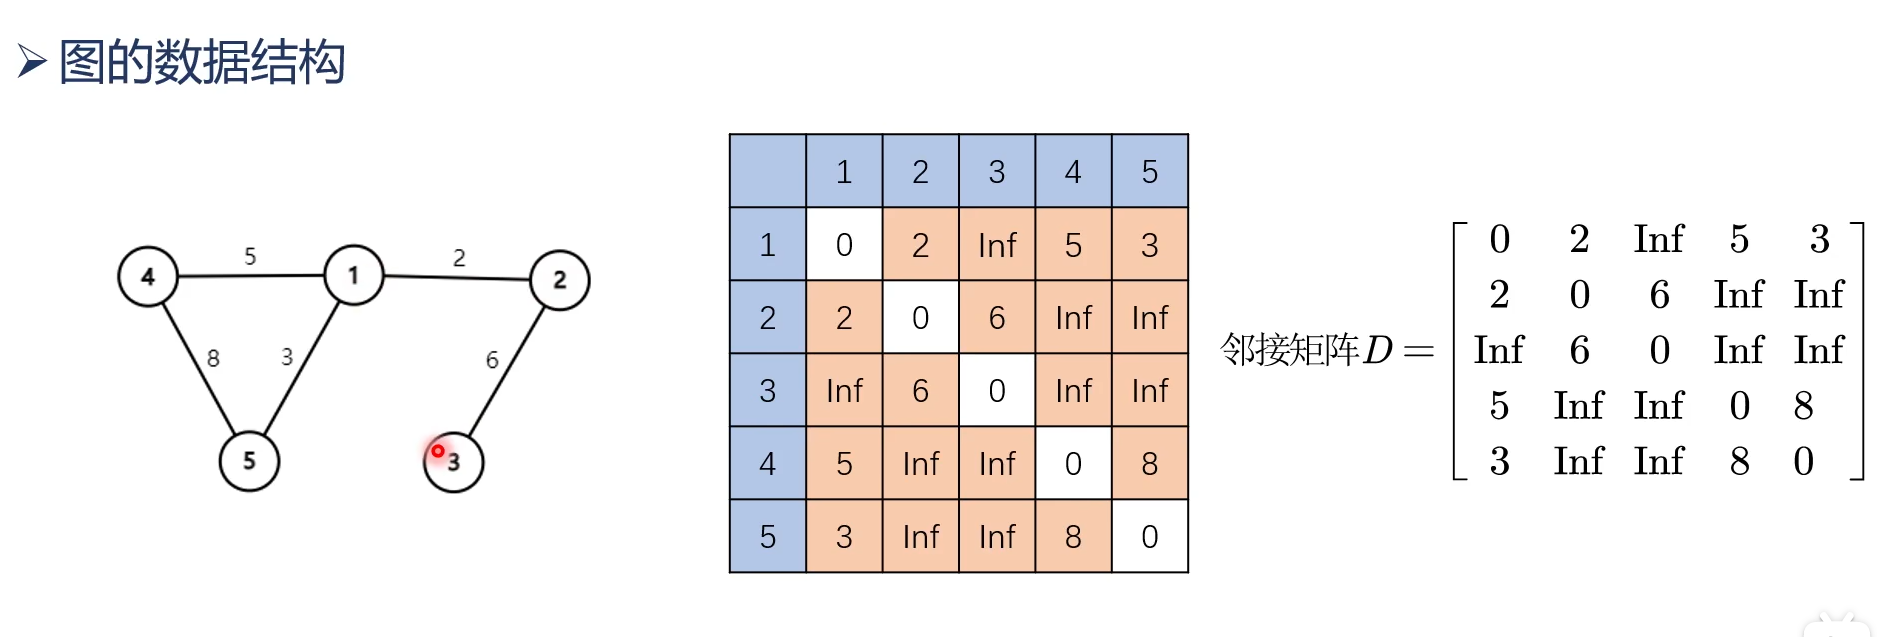

## 最短路径问题：计算通过两点的最短路径
- 算法：整数规划

In [1]:
import pulp

def shortest_path(nodes, edges, source, target):

    problem = pulp.LpProblem(
        "Shortest_Path",
        pulp.LpMinimize
    )

    x = {
        edge: pulp.LpVariable(
            f"x_{edge[0]}_{edge[1]}",
            cat="Binary"
        )
        for edge in edges
    }

    problem += pulp.lpSum(
        edges[edge] * x[edge]
        for edge in edges
    )

    for node in nodes:

        outgoing = pulp.lpSum(
            x[(i, j)]
            for (i, j) in edges
            if i == node
        )

        incoming = pulp.lpSum(
            x[(i, j)]
            for (i, j) in edges
            if j == node
        )

        if node == source:
            problem += outgoing - incoming == 1

        elif node == target:
            problem += outgoing - incoming == -1

        else:
            problem += outgoing - incoming == 0

    problem.solve(
        pulp.PULP_CBC_CMD(msg=False)
    )

    selected_edges = [
        edge
        for edge in edges
        if pulp.value(x[edge]) > 0.5
    ]

    path = [source]
    current = source

    while current != target:

        for i, j in selected_edges:

            if i == current:
                path.append(j)
                current = j
                break

    distance = pulp.value(problem.objective)

    return path, distance


nodes = [1, 2, 3, 4, 5, 6]

edges = {
    (1, 2): 4,
    (1, 3): 2,
    (2, 4): 3,
    (3, 4): 2,
    (3, 5): 5,
    (4, 6): 1,
    (5, 6): 2
}

path, distance = shortest_path(
    nodes,
    edges,
    source=1,
    target=6
)

print("最短路径：", path)
print("最短距离：", distance)

最短路径： [1, 3, 4, 6]
最短距离： 5.0


## Dijkstra 算法
- 原理：

假设我们从起点 s 出发。

Dijkstra 会维护一个数组：

dist[v]

表示：

目前已知的从 s 到 v 的最短距离

一开始：

dist[s]=0

其他点都不知道怎么到达，所以设成：

dist[v]=+∞.

然后算法不断做一件事：

在所有“还没有确定最短距离”的节点中，选择当前 dist 最小的那个节点。

一旦选择了这个节点，它的最短距离就可以正式确定。

然后用这个节点去尝试更新它周围的邻居。

In [2]:
def dijkstra(graph, start):
    nodes = list(graph.keys())

    dist = {node: float("inf") for node in nodes}
    prev = {node: None for node in nodes}

    dist[start] = 0

    visited = set()

    while len(visited) < len(nodes):
        current = None
        current_dist = float("inf")

        # 找到当前距离最小的未访问节点
        for node in nodes:
            if node not in visited and dist[node] < current_dist:
                current = node
                current_dist = dist[node]

        if current is None:
            break

        visited.add(current)

        # 松弛
        for neighbor, weight in graph[current]:
            new_dist = dist[current] + weight

            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                prev[neighbor] = current

    return dist, prev

def get_path(prev, start, target):
    path = []

    current = target

    while current is not None:
        path.append(current)

        if current == start:
            break

        current = prev[current]

    path.reverse()

    return path


graph = {
    1: [(2, 4), (3, 2)],
    2: [(4, 3)],
    3: [(4, 2), (5, 5)],
    4: [(6, 1)],
    5: [(6, 2)],
    6: []
}
dist, prev = dijkstra(graph, 1)

path = get_path(prev, 1, 6)

print("最短距离：", dist[6])
print("最短路径：", path)

最短距离： 5
最短路径： [1, 3, 4, 6]


### 上面的代码是比较粗糙的，我们使用最小堆将代码的时间复杂度降低

In [3]:
import heapq

def dijkstra(graph, start):
    dist = {
        node: float("inf")
        for node in graph
    }

    prev = {
        node: None
        for node in graph
    }

    dist[start] = 0

    # (距离, 节点)
    heap = [(0, start)]

    while heap:
        current_dist, current = heapq.heappop(heap)

        # 如果这是一个旧数据，跳过
        if current_dist > dist[current]:
            continue

        # 松弛邻边
        for neighbor, weight in graph[current]:
            new_dist = current_dist + weight

            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                prev[neighbor] = current

                heapq.heappush(
                    heap,
                    (new_dist, neighbor)
                )

    return dist, prev

## 网络最大流问题
- （一）流量图  
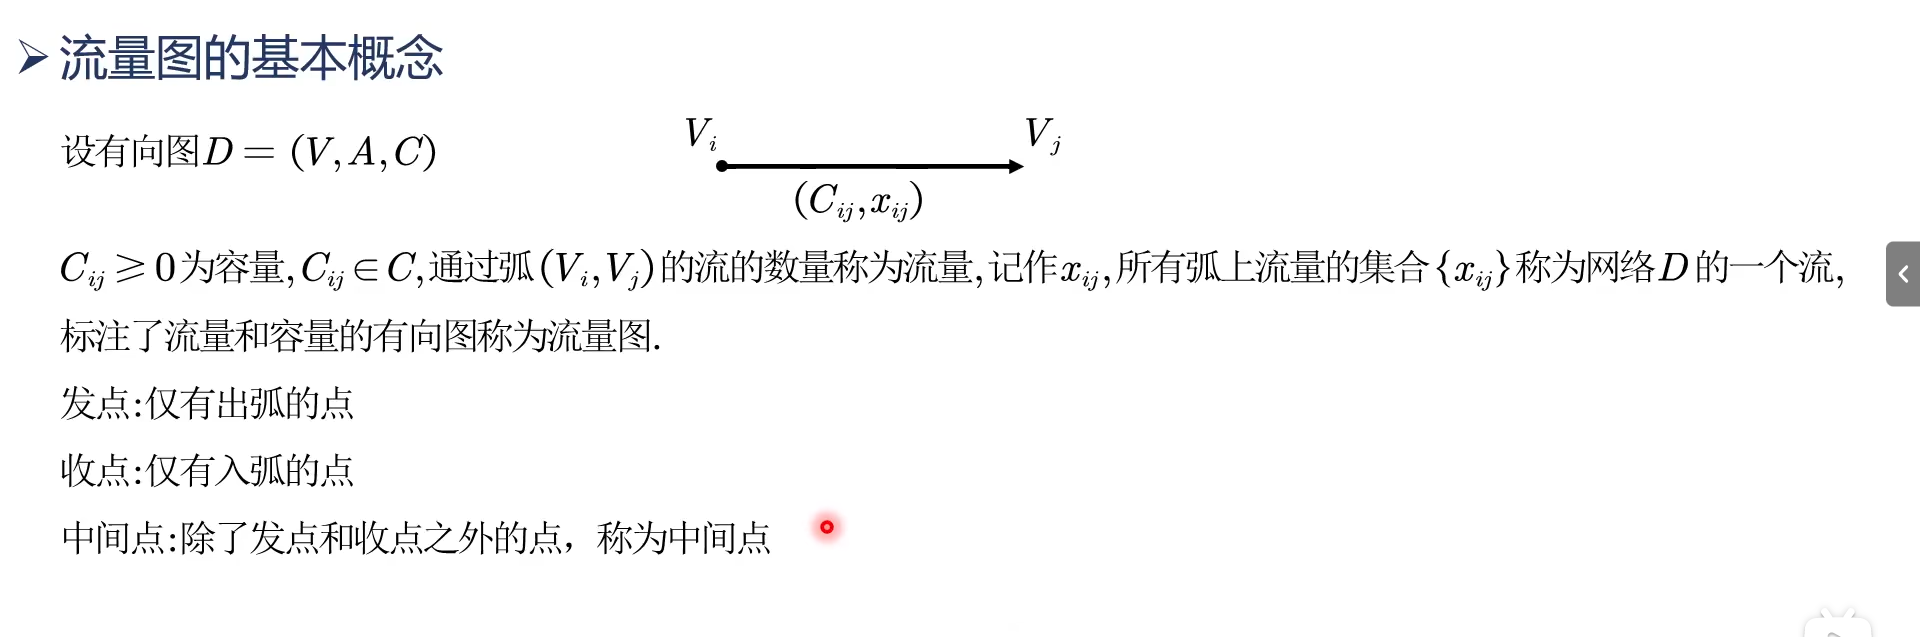

- （二）可行流  
满足以下条件的流量图为可行流：  
1. 出发点的流出量等于终止点的流入量  
2. 中间点的流出量等于其流入量  

- （三）增广路  
如果一条连接首位的路（可反向，反向的称为反向弧）的流量可以增加，则成为增广路


## Ford-Fulkerson算法
算法原理：从出发点，遍历所有通往终点的路，寻找增广路  
计算链接两个节点的剩余流量，记录增广路上所有剩余流量的最小值，更新流量图  
重复以上过程，直至便利所有路线  

In [2]:
def ford_fulkerson(capacity, source, sink):
    n = len(capacity)

    # 剩余容量网络
    residual = [row[:] for row in capacity]

    max_flow = 0

    while True:
        # parent[v]记录搜索路径中v的父节点
        parent = [-1] * n
        visited = [False] * n

        stack = [source]
        visited[source] = True

        # DFS寻找增广路
        while stack:
            u = stack.pop()

            for v in range(n):
                if not visited[v] and residual[u][v] > 0:
                    visited[v] = True
                    parent[v] = u
                    stack.append(v)

        # 无法到达汇点
        if not visited[sink]:
            break

        # 计算瓶颈容量
        path_flow = float("inf")

        v = sink

        while v != source:
            u = parent[v]
            path_flow = min(path_flow, residual[u][v])
            v = u

        # 更新剩余网络
        v = sink

        while v != source:
            u = parent[v]

            residual[u][v] -= path_flow
            residual[v][u] += path_flow

            v = u

        max_flow += path_flow

    return max_flow

### 算法使用：
输入以下数据
1. capacity: 最大容量矩阵  
2. flow: 已有流量矩阵
3. 原点 source 和终点 sink 的编号

In [4]:
capacity = [
    # Vs  1  2  3   4  5  Vt
    [ 0,  4, 0, 3, 10, 0, 0],  # Vs
    [ 0,  0, 1, 3,  0, 0, 0],  # 1
    [ 0,  0, 0, 0,  0, 0, 7],  # 2
    [ 0,  0, 4, 0,  0, 5, 0],  # 3
    [ 0,  0, 0, 3,  0, 4, 0],  # 4
    [ 0,  0, 2, 0,  0, 0, 8],  # 5
    [ 0,  0, 0, 0,  0, 0, 0],  # Vt
]
flow = [
    # Vs  1  2  3  4  5  Vt
    [ 0,  3, 0, 2, 4, 0, 0],  # Vs
    [ 0,  0, 1, 2, 0, 0, 0],  # 1
    [ 0,  0, 0, 0, 0, 0, 6],  # 2
    [ 0,  0, 3, 0, 0, 3, 0],  # 3
    [ 0,  0, 0, 2, 0, 2, 0],  # 4
    [ 0,  0, 2, 0, 0, 0, 3],  # 5
    [ 0,  0, 0, 0, 0, 0, 0],  # Vt
]

max_flow = ford_fulkerson(
    capacity,
    source=0,
    sink=6
)

print(max_flow)


14


## 最小费用最大流
